# Missouri's Issue Space: Eight Measures, One Electorate's Character

*An analysis notebook for the Geo-Fluid Dynamics Engine. Exploratory
narrative — the tested library (`geofluid`) does the real computation.*

## The question (plain language)

When a county defies its partisan reputation on one issue, does it defy it
on others too? Ohio's two-issue 2023 ballot said yes (r ≈ 0.62) but with a
caveat: abortion and cannabis share a "personal liberty" flavor. Missouri's
canvasses give us the decisive test — **eight statewide measures on the
same 116 jurisdictions** spanning abortion, cannabis (three competing
measures), minimum wage (twice, six years apart), right-to-work, and
Medicaid expansion, across three electorate types (presidential general,
midterm general, August primary).

## The bottom line

* **The trait is general, not a libertarian-cluster artifact.** On the same
  2024 ballot, abortion resistance and minimum-wage resistance — a social
  measure and an economic one — correlate strongly. A county that runs
  ahead of its partisan peers on one axis runs ahead on the other.
* **The trait is durable.** Minimum-wage resistance in 2018 predicts
  minimum-wage resistance in 2024 across six years and two different
  electorates.
* **The trait does NOT cross electorate types cleanly.** General-election
  measures cohere with each other; the two August-primary measures cohere
  with each other; the two blocks barely correlate. WHO SHOWS UP is part of
  what a jurisdiction's "character" is — and the single biggest modeling
  risk for predicting a midterm measure from presidential-year baselines.

## Why it matters

The 2026 pre-registration experiment (docs/MEASUREMENT_DESIGN.md §7) rests
on exactly these three facts: cross-issue borrowing makes every past
measure informative about the 2026 abortion vote; durability makes 2018
data admissible; and the electorate-type block structure says the turnout
adjustment is where the prediction will be won or lost.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from geofluid.dissonance import issue_resistance
from geofluid.ingest.referendum import load_mo_referendum

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())

## Setup: jurisdictions, partisanship, and the eight measures

Missouri reports 116 jurisdictions: 114 counties, St. Louis City, and
**Kansas City** — which spans four counties and carries MIT's place-code
convention `2938000` (MIT's presidential file reports KC separately too, so
it has a real partisan baseline; the loader's unknown-name guard forced
this decision into the open — see BACKLOG).

In [2]:
mit = pd.read_csv(
    ROOT / "data/raw/countypres_2000-2024.csv",
    dtype={"county_fips": "string"},
    low_memory=False,
)
mo_rows = mit[mit["state_po"] == "MO"]
names = mo_rows[["county_name", "county_fips"]].drop_duplicates()
fips_map = {
    str(n).title(): str(f).zfill(5)
    for n, f in zip(names["county_name"], names["county_fips"], strict=True)
}
fips_map.update(
    {
        "Kansas City": "2938000",  # MIT place-code convention (spans 4 counties)
        "McDonald": "29119",  # str.title() yields "Mcdonald"
        "St. Louis": "29189",  # the canvass drops the "County" suffix
    }
)


def dem_two_party(year: int) -> "pd.Series[float]":
    y = mo_rows[mo_rows["year"] == year].copy()
    y["fips"] = y["county_name"].str.title().map(fips_map)
    two = y[y["party"].isin(["DEMOCRAT", "REPUBLICAN"])]
    pv = two.pivot_table(index="fips", columns="party", values="candidatevotes", aggfunc="sum")
    return pv["DEMOCRAT"] / (pv["DEMOCRAT"] + pv["REPUBLICAN"])


dem = {year: dem_two_party(year) for year in (2016, 2020, 2024)}

# Each measure is residualized against its own era's partisanship so that
# 2016->2024 realignment drift cannot leak into the resistance residuals:
# 2018 measures use the mean of the flanking presidentials (2016, 2020).
BASELINE = {
    2018: (dem[2016] + dem[2020]) / 2,
    2020: dem[2020],
    2024: dem[2024],
}

# (label, canvass, contest, progressive side, measure year, electorate type)
MEASURES = [
    ("abortion_2024", "ActualResults-November52024.pdf", "Amendment 3", "yes", 2024, "general"),
    ("minwage_2024", "ActualResults-November52024.pdf", "Proposition A", "yes", 2024, "general"),
    (
        "minwage_2018",
        "ActualResults-November62018-FINAL.pdf",
        "Proposition B",
        "yes",
        2018,
        "general",
    ),
    (
        "cannabis_2018a",
        "ActualResults-November62018-FINAL.pdf",
        "Amendment 2",
        "yes",
        2018,
        "general",
    ),
    (
        "cannabis_2018b",
        "ActualResults-November62018-FINAL.pdf",
        "Amendment 3",
        "yes",
        2018,
        "general",
    ),
    (
        "cannabis_2018c",
        "ActualResults-November62018-FINAL.pdf",
        "Proposition C",
        "yes",
        2018,
        "general",
    ),
    ("rtw_2018", "ActualResults-August72018.pdf", "Proposition A", "no", 2018, "primary"),
    ("medicaid_2020", "ActualResults-August42020.pdf", "Amendment 2", "yes", 2020, "primary"),
]

progressive = {}
for label, canvass, contest, side, _year, _etype in MEASURES:
    panel = load_mo_referendum(ROOT / "data/raw" / canvass, contest, fips_map)
    panel = panel.set_index("fips")
    share = 1 - panel["no_share"] if side == "yes" else panel["no_share"]
    progressive[label] = share
prog = pd.DataFrame(progressive)
print(f"progressive-share panel: {prog.shape[0]} jurisdictions x {prog.shape[1]} measures")

progressive-share panel: 116 jurisdictions x 8 measures


## The resistance grid

`dissonance.issue_resistance` residualizes each measure's progressive share
on partisanship (OLS across jurisdictions) — the rigorous "defies its
partisan peers" trait. The grid below is the correlation of those residuals
across all eight measures.

                abortion_2024  minwage_2024  minwage_2018  cannabis_2018a  cannabis_2018b  cannabis_2018c  rtw_2018  medicaid_2020
abortion_2024            1.00          0.52          0.29            0.39            0.18            0.22      0.09           0.17
minwage_2024             0.52          1.00          0.68            0.41            0.63            0.60     -0.12           0.11
minwage_2018             0.29          0.68          1.00            0.50            0.46            0.50      0.19           0.37
cannabis_2018a           0.39          0.41          0.50            1.00            0.38            0.55      0.29           0.27
cannabis_2018b           0.18          0.63          0.46            0.38            1.00            0.82     -0.30          -0.15
cannabis_2018c           0.22          0.60          0.50            0.55            0.82            1.00     -0.20           0.01
rtw_2018                 0.09         -0.12          0.19            0.29          

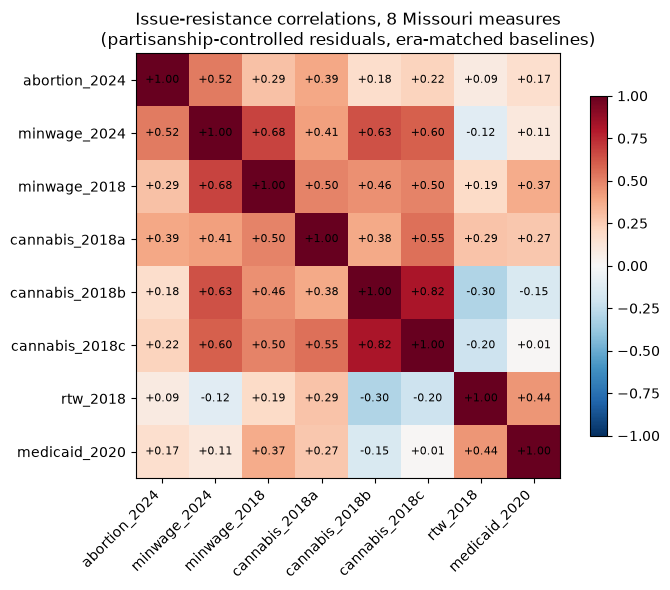

In [3]:
resid = pd.DataFrame(
    {
        label: issue_resistance(prog[label], BASELINE[year])
        for label, _c, _n, _s, year, _e in MEASURES
    }
)
grid = resid.corr()
print(grid.round(2).to_string())

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(grid.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(grid)), grid.columns, rotation=45, ha="right")
ax.set_yticks(range(len(grid)), grid.columns)
for i in range(len(grid)):
    for j in range(len(grid)):
        ax.text(j, i, f"{grid.values[i, j]:+.2f}", ha="center", va="center", fontsize=8)
ax.set_title(
    "Issue-resistance correlations, 8 Missouri measures\n"
    "(partisanship-controlled residuals, era-matched baselines)"
)
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

## The three headline numbers

In [4]:
cross_cluster = grid.loc["abortion_2024", "minwage_2024"]
within_issue = grid.loc["minwage_2018", "minwage_2024"]
sanity_twins = grid.loc["cannabis_2018b", "cannabis_2018c"]

primary = [m[0] for m in MEASURES if m[5] == "primary"]
general = [m[0] for m in MEASURES if m[5] == "general"]
gg = grid.loc[general, general].values
gg_mean = gg[~np.eye(len(general), dtype=bool)].mean()
pg_mean = grid.loc[primary, general].values.mean()
pp = grid.loc[primary[0], primary[1]]

print(f"cross-cluster, same ballot (abortion x minwage 2024): {cross_cluster:+.2f}")
print(f"within-issue, six years apart (minwage 2018 x 2024):  {within_issue:+.2f}")
print(f"sanity anchor (competing 2018 cannabis twins):        {sanity_twins:+.2f}")
print(f"mean general x general: {gg_mean:+.2f}")
print(f"mean primary x general: {pg_mean:+.2f}   primary x primary: {pp:+.2f}")

cross-cluster, same ballot (abortion x minwage 2024): +0.52
within-issue, six years apart (minwage 2018 x 2024):  +0.68
sanity anchor (competing 2018 cannabis twins):        +0.82
mean general x general: +0.47
mean primary x general: +0.06   primary x primary: +0.44


## Robustness: does the baseline choice drive the result?

The scratch version of this analysis used the 2024 partisan map for every
measure. If the headline numbers moved materially under era-matched
baselines, the "trait" would partly be realignment drift in disguise.

In [5]:
resid_2024base = pd.DataFrame(
    {label: issue_resistance(prog[label], dem[2024]) for label in prog.columns}
)
grid_2024base = resid_2024base.corr()
compare = pd.DataFrame(
    {
        "era-matched": [
            grid.loc["abortion_2024", "minwage_2024"],
            grid.loc["minwage_2018", "minwage_2024"],
        ],
        "2024-baseline": [
            grid_2024base.loc["abortion_2024", "minwage_2024"],
            grid_2024base.loc["minwage_2018", "minwage_2024"],
        ],
    },
    index=["cross-cluster 2024", "within-issue 2018x2024"],
).round(3)
print(compare.to_string())

                        era-matched  2024-baseline
cross-cluster 2024            0.521          0.521
within-issue 2018x2024        0.678          0.683


## Who defies hardest? (the 2026-relevant tails)

In [6]:
spotlight = pd.DataFrame(
    {
        "abortion_resist_2024": resid["abortion_2024"],
        "minwage_resist_2024": resid["minwage_2024"],
        "dem2p_2024": dem[2024],
    }
).dropna()
print("most abortion-resistant-ABOVE-partisanship (top 5):")
print(spotlight.nlargest(5, "abortion_resist_2024").round(3).to_string())
print("\nmost BELOW-partisanship (top 5):")
print(spotlight.nsmallest(5, "abortion_resist_2024").round(3).to_string())

most abortion-resistant-ABOVE-partisanship (top 5):
       abortion_resist_2024  minwage_resist_2024  dem2p_2024
fips                                                        
29045                 0.074                0.065       0.190
29005                 0.070                0.076       0.197
29029                 0.069                0.013       0.226
29195                 0.065               -0.000       0.296
29177                 0.055                0.044       0.254

most BELOW-partisanship (top 5):
       abortion_resist_2024  minwage_resist_2024  dem2p_2024
fips                                                        
29510                -0.071               -0.006       0.830
29229                -0.063               -0.040       0.119
29011                -0.063               -0.065       0.137
29151                -0.063               -0.071       0.132
29017                -0.061               -0.076       0.124


## What this means for the 2026 prediction

1. **Borrow strength across issues.** The cross-cluster correlation means
   every one of a county's past measure votes is informative about its 2026
   abortion vote — the prediction can rank on a pooled trait, not one
   noisy baseline.
2. **2018 data is admissible.** Six-year durability licenses the full
   eight-measure history as training signal.
3. **Model the electorate, not just the county.** The general/primary block
   structure is the quantified version of the design doc's turnout warning
   — and the certified Aug-2026 primary results (Matt's September do-out)
   become the bridge observation between electorate types in the 2026
   cycle itself.

*Caveats:* one state; jurisdictions are aggregates (no individual claims);
the KC pseudo-jurisdiction's partisan baseline comes from MIT's separate KC
reporting, not a county FIPS; and "primary vs general" is confounded with
issue (right-to-work and Medicaid only appear in primaries here) — the 2026
calibration set is what can separate those.